<a href="https://colab.research.google.com/github/AlbertoPS93/Finance/blob/main/HormuzLinkedNote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#!/usr/bin/env python3
"""
═══════════════════════════════════════════════════════════════════════════════
  HORMUZ LINKED NOTE — VERSIÓN PARAMÉTRICA (Colab-ready)
  Cambia FECHA_INCEPTION y todo se recalcula automáticamente
═══════════════════════════════════════════════════════════════════════════════
"""

import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d
from datetime import datetime, timedelta
from IPython.display import display
import warnings
warnings.filterwarnings("ignore", message=".*findfont.*")

import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ═══════════════════════════════════════════════════════════════════════════
#  ★★★  PARÁMETRO PRINCIPAL — MODIFICA ESTA FECHA  ★★★
# ═══════════════════════════════════════════════════════════════════════════

FECHA_INCEPTION = datetime(2026, 3, 1)   # ← CAMBIA AQUÍ (formato: año, mes, día)

# ═══════════════════════════════════════════════════════════════════════════
#  CONSTANTES DEL PRODUCTO
# ═══════════════════════════════════════════════════════════════════════════

NOCIONAL        = 1_000_000
HORIZONTE_MESES = 18
T               = HORIZONTE_MESES / 12
K1              = 85.0
K2              = 130.0
BDTI_TRIGGER    = 1800
DIGITAL_PAYOFF  = 0.15
BDTI_VOL        = 0.45
R_FREE          = 0.043

FECHA_HOY         = datetime(2026, 3, 11)
FECHA_VENCIMIENTO = FECHA_INCEPTION + timedelta(days=int(T * 365.25))
T_RESIDUAL        = (FECHA_VENCIMIENTO - FECHA_HOY).days / 365.25
dias_transcurridos = (FECHA_HOY - FECHA_INCEPTION).days

# ═══════════════════════════════════════════════════════════════════════════
#  TIMELINE DE MERCADO
# ═══════════════════════════════════════════════════════════════════════════

TIMELINE = [
    (datetime(2026, 1, 15),  63.0,  0.28,   750,    0),
    (datetime(2026, 2,  1),  65.0,  0.28,   780,    0),
    (datetime(2026, 2, 10),  68.0,  0.30,   800,   10),
    (datetime(2026, 2, 15),  68.0,  0.32,   820,   15),
    (datetime(2026, 2, 20),  67.5,  0.30,   790,   10),
    (datetime(2026, 2, 25),  69.0,  0.34,   850,   25),
    (datetime(2026, 2, 28),  73.0,  0.40,  1000,   60),
    (datetime(2026, 3,  1),  76.0,  0.42,  1100,   80),
    (datetime(2026, 3,  3),  83.0,  0.48,  1250,  100),
    (datetime(2026, 3,  5),  82.0,  0.50,  1300,  110),
    (datetime(2026, 3,  7),  88.0,  0.52,  1350,  120),
    (datetime(2026, 3,  9),  94.0,  0.55,  1400,  130),
    (datetime(2026, 3, 10),  87.8,  0.55,  1420,  125),
    (datetime(2026, 3, 11),  91.6,  0.55,  1450,  130),
]

def interpolar_mercado(fecha):
    dias = np.array([(d - TIMELINE[0][0]).days for d, *_ in TIMELINE])
    t_dias = np.clip((fecha - TIMELINE[0][0]).days, dias[0], dias[-1])
    return {k: float(interp1d(dias, np.array([row[i] for row in TIMELINE]), kind="linear")(t_dias))
            for i, k in enumerate(["brent", "vol", "bdti", "spread_add"], 1)}

mkt_inception = interpolar_mercado(FECHA_INCEPTION)
mkt_hoy       = interpolar_mercado(FECHA_HOY)

BRENT_INCEPTION = mkt_inception["brent"]
VOL_INCEPTION   = mkt_inception["vol"]
BDTI_INCEPTION  = mkt_inception["bdti"]
BRENT_HOY       = mkt_hoy["brent"]
VOL_HOY         = mkt_hoy["vol"]
BDTI_HOY_EST    = mkt_hoy["bdti"]
spread_crisis_bp = max(0, mkt_hoy["spread_add"] - mkt_inception["spread_add"])

# ═══════════════════════════════════════════════════════════════════════════
#  FUNCIONES DE PRICING
# ═══════════════════════════════════════════════════════════════════════════

def bs_call(S, K, T, r, sigma):
    if T <= 0: return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_digital_call(S, K, T, r, sigma):
    if T <= 0: return 1.0 if S >= K else 0.0
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d2)

# ═══════════════════════════════════════════════════════════════════════════
#  CÁLCULOS
# ═══════════════════════════════════════════════════════════════════════════

cupon_pond = 0.0587; dm_pond = 1.16
carry_anual = NOCIONAL * cupon_pond; carry_18m = carry_anual * T
barriles_nocional = NOCIONAL / K1

spread_inception      = bs_call(BRENT_INCEPTION, K1, T, R_FREE, VOL_INCEPTION) - bs_call(BRENT_INCEPTION, K2, T, R_FREE, VOL_INCEPTION)
prima_total_inception = spread_inception * barriles_nocional
spread_hoy            = bs_call(BRENT_HOY, K1, T_RESIDUAL, R_FREE, VOL_HOY) - bs_call(BRENT_HOY, K2, T_RESIDUAL, R_FREE, VOL_HOY)
valor_spread_hoy      = spread_hoy * barriles_nocional
breakeven             = K1 + spread_inception

prob_inception          = bs_digital_call(BDTI_INCEPTION, BDTI_TRIGGER, T, R_FREE, BDTI_VOL)
digital_price_inception = prob_inception * DIGITAL_PAYOFF * NOCIONAL
prob_hoy                = bs_digital_call(BDTI_HOY_EST, BDTI_TRIGGER, T_RESIDUAL, R_FREE, BDTI_VOL)
digital_valor_hoy       = prob_hoy * DIGITAL_PAYOFF * NOCIONAL

coste_opciones_total = prima_total_inception + digital_price_inception
carry_neto_18m       = carry_18m - coste_opciones_total
carry_neto_anual     = carry_anual - coste_opciones_total / T

# Escenarios
escenarios = [
    {"nombre": "Desescalada total",   "brent": 65,  "bdti": 700,  "spread_chg_bp": -50,  "prob": 0.15},
    {"nombre": "Desescalada parcial", "brent": 75,  "bdti": 800,  "spread_chg_bp": -20,  "prob": 0.15},
    {"nombre": "Base (sin cambio)",   "brent": 85,  "bdti": 950,  "spread_chg_bp":   0,  "prob": 0.25},
    {"nombre": "Escalada moderada",   "brent": 105, "bdti": 1400, "spread_chg_bp": +80,  "prob": 0.20},
    {"nombre": "Escalada severa",     "brent": 120, "bdti": 1900, "spread_chg_bp": +150, "prob": 0.15},
    {"nombre": "Cierre de Ormuz",     "brent": 135, "bdti": 2500, "spread_chg_bp": +250, "prob": 0.10},
]

esc_labels, esc_p1, esc_p2, esc_p3, esc_total = [], [], [], [], []
retorno_esperado_ponderado = 0
for esc in escenarios:
    p1 = carry_18m + (-dm_pond * (esc["spread_chg_bp"] / 10000) * NOCIONAL)
    p2 = (max(esc["brent"]-K1, 0) - max(esc["brent"]-K2, 0)) * barriles_nocional - prima_total_inception
    p3 = (DIGITAL_PAYOFF * NOCIONAL if esc["bdti"] >= BDTI_TRIGGER else 0) - digital_price_inception
    total = p1 + p2 + p3
    retorno_esperado_ponderado += total * esc["prob"]
    esc_labels.append(esc["nombre"].replace(" ", "\n"))
    esc_p1.append(p1); esc_p2.append(p2); esc_p3.append(p3); esc_total.append(total)
p1a, p2a, p3a, ta = np.array(esc_p1), np.array(esc_p2), np.array(esc_p3), np.array(esc_total)

# MtM
carry_acumulado    = carry_anual * (dias_transcurridos / 365.25)
impacto_spread_mtm = -dm_pond * (spread_crisis_bp / 10000) * NOCIONAL
pata1_mtm = carry_acumulado + impacto_spread_mtm
pata2_mtm = valor_spread_hoy - prima_total_inception
pata3_mtm = digital_valor_hoy - digital_price_inception
total_mtm = pata1_mtm + pata2_mtm + pata3_mtm

# ═══════════════════════════════════════════════════════════════════════════
#  OUTPUT
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("  HORMUZ LINKED NOTE — ANÁLISIS PARAMÉTRICO")
print("=" * 72)
print(f"""
  INCEPTION: {FECHA_INCEPTION.strftime('%d %b %Y')}
    Brent:   ${BRENT_INCEPTION:.2f}   Vol: {VOL_INCEPTION:.0%}   BDTI: {BDTI_INCEPTION:.0f}

  HOY:       {FECHA_HOY.strftime('%d %b %Y')} (+{dias_transcurridos} días)
    Brent:   ${BRENT_HOY:.2f}   Vol: {VOL_HOY:.0%}   BDTI: {BDTI_HOY_EST:.0f}

  COSTES:
    Prima call spread:    ${prima_total_inception:>12,.0f}  ({prima_total_inception/NOCIONAL*100:.2f}%)
    Prima digital:        ${digital_price_inception:>12,.0f}  ({digital_price_inception/NOCIONAL*100:.2f}%)
    Carry bruto (18M):    ${carry_18m:>12,.0f}
    Carry neto (18M):     ${carry_neto_18m:>+12,.0f}  ({carry_neto_18m/NOCIONAL*100:+.2f}%)
    Breakeven Brent:      ${breakeven:>12.2f}/bbl

  MARK-TO-MARKET:
    Pata 1 (Bond Floor):  ${pata1_mtm:>+12,.0f}
    Pata 2 (Call Spread): ${pata2_mtm:>+12,.0f}
    Pata 3 (Digital):     ${pata3_mtm:>+12,.0f}
    ──────────────────────────────
    TOTAL P&L:            ${total_mtm:>+12,.0f}  ({total_mtm/NOCIONAL*100:+.2f}%)

  ESCENARIOS A VENCIMIENTO:
    Peor caso:            ${min(esc_total):>+12,.0f}  ({min(esc_total)/NOCIONAL*100:+.1f}%)
    Retorno esperado:     ${retorno_esperado_ponderado:>+12,.0f}  ({retorno_esperado_ponderado/NOCIONAL*100:+.1f}%)
    Mejor caso:           ${max(esc_total):>+12,.0f}  ({max(esc_total)/NOCIONAL*100:+.1f}%)
""")

  HORMUZ LINKED NOTE — ANÁLISIS PARAMÉTRICO

  INCEPTION: 01 Mar 2026
    Brent:   $76.00   Vol: 42%   BDTI: 1100

  HOY:       11 Mar 2026 (+10 días)
    Brent:   $91.60   Vol: 55%   BDTI: 1450

  COSTES:
    Prima call spread:    $     109,520  (10.95%)
    Prima digital:        $      20,585  (2.06%)
    Carry bruto (18M):    $      88,050
    Carry neto (18M):     $     -42,055  (-4.21%)
    Breakeven Brent:      $       94.31/bbl

  MARK-TO-MARKET:
    Pata 1 (Bond Floor):  $      -4,193
    Pata 2 (Call Spread): $     +50,890
    Pata 3 (Digital):     $     +20,258
    ──────────────────────────────
    TOTAL P&L:            $     +66,955  (+6.70%)

  ESCENARIOS A VENCIMIENTO:
    Peor caso:            $     -42,055  (-4.2%)
    Retorno esperado:     $    +151,062  (+15.1%)
    Mejor caso:           $    +608,357  (+60.8%)



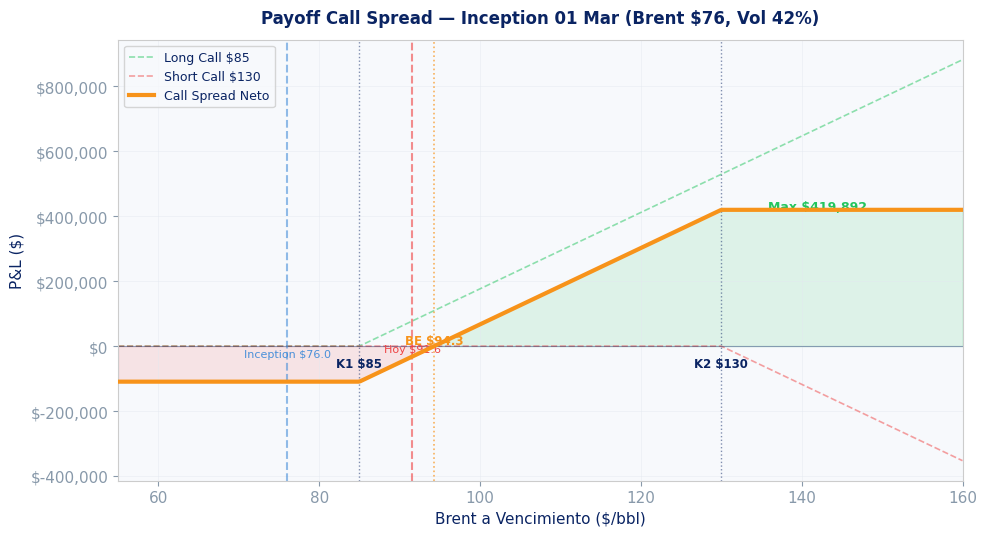

/tmp/ipykernel_486/2126462019.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(); display(fig); plt.close(fig)


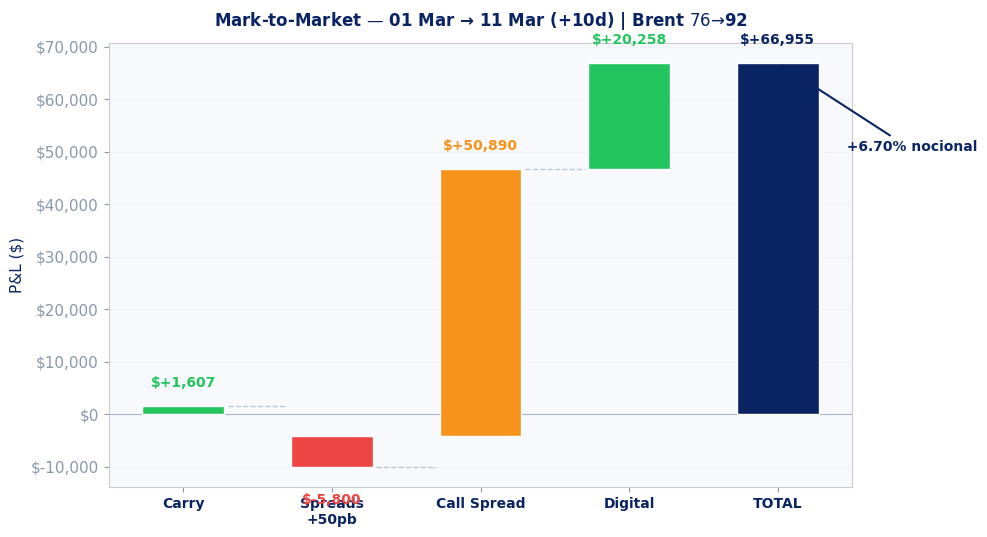

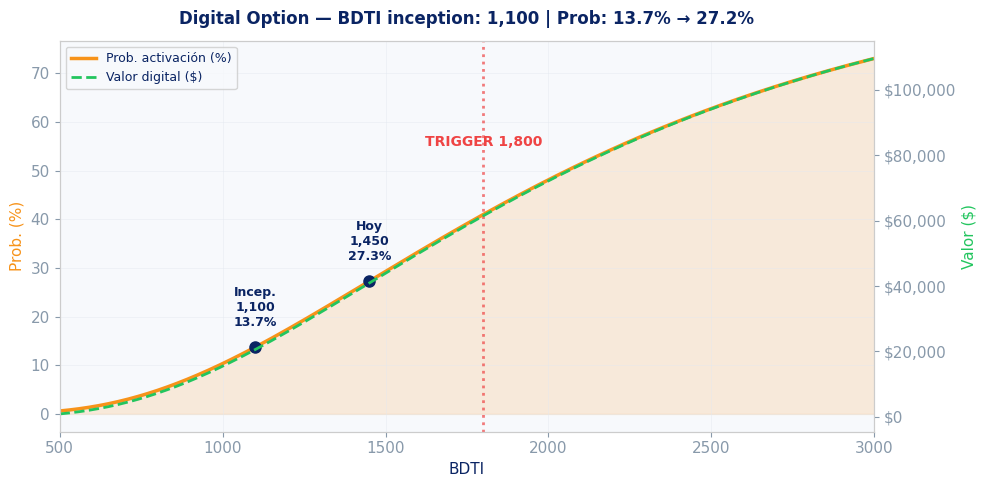

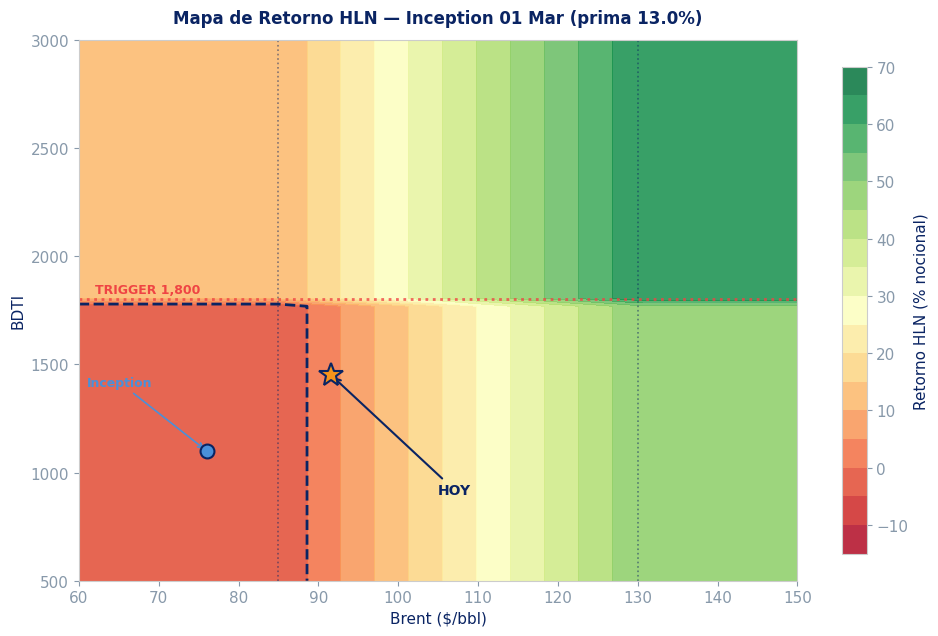

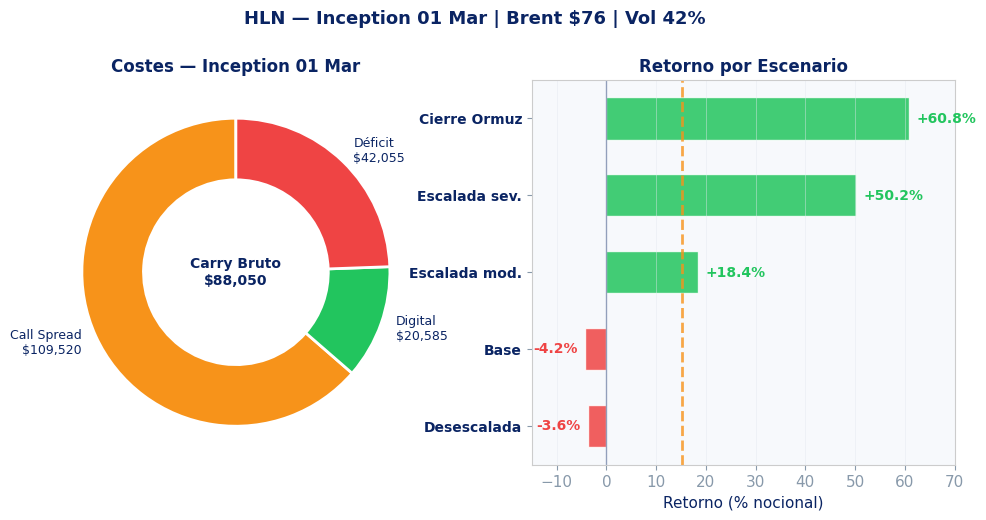

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUALIZACIONES
# ═══════════════════════════════════════════════════════════════════════════

NAVY = "#0A2463"; ORANGE = "#F7931A"; LIGHT_BLUE = "#4A90D9"
GREEN = "#22C55E"; RED = "#EF4444"; GRAY = "#8899AA"

plt.rcParams.update({
    "font.size": 11,
    "axes.facecolor": "#F7F9FC", "figure.facecolor": "#FFFFFF",
    "axes.edgecolor": "#CCCCCC", "axes.labelcolor": NAVY,
    "text.color": NAVY, "xtick.color": GRAY, "ytick.color": GRAY,
    "grid.color": "#E2E8F0", "grid.linewidth": 0.6,
})
inception_label = FECHA_INCEPTION.strftime("%d %b")


# ── FIG 1: PAYOFF CALL SPREAD ──

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5.5))
brent = np.linspace(55, 160, 500)
payoff_neto = (np.maximum(brent-K1, 0) - np.maximum(brent-K2, 0) - spread_inception) * barriles_nocional
ax.fill_between(brent, payoff_neto, 0, where=(payoff_neto < 0), alpha=0.12, color=RED)
ax.fill_between(brent, payoff_neto, 0, where=(payoff_neto >= 0), alpha=0.12, color=GREEN)
ax.plot(brent, np.maximum(brent-K1, 0)*barriles_nocional, "--", color=GREEN, alpha=0.5, lw=1.2, label="Long Call $85")
ax.plot(brent, -np.maximum(brent-K2, 0)*barriles_nocional, "--", color=RED, alpha=0.5, lw=1.2, label="Short Call $130")
ax.plot(brent, payoff_neto, color=ORANGE, lw=3, label="Call Spread Neto", zorder=5)
ax.axhline(0, color=NAVY, lw=0.8, alpha=0.4)
ax.axvline(K1, color=NAVY, ls=":", lw=1, alpha=0.5); ax.axvline(K2, color=NAVY, ls=":", lw=1, alpha=0.5)
ax.axvline(breakeven, color=ORANGE, ls=":", lw=1.2, alpha=0.7)
ax.axvline(BRENT_INCEPTION, color=LIGHT_BLUE, ls="--", lw=1.5, alpha=0.6)
ax.axvline(BRENT_HOY, color=RED, ls="--", lw=1.5, alpha=0.6)
ax.annotate(f"K1 $85", xy=(K1, -prima_total_inception*0.6), fontsize=8.5, ha="center", color=NAVY, weight="bold")
ax.annotate(f"K2 $130", xy=(K2, -prima_total_inception*0.6), fontsize=8.5, ha="center", color=NAVY, weight="bold")
ax.annotate(f"BE ${breakeven:.1f}", xy=(breakeven, 8000), fontsize=8.5, ha="center", color=ORANGE, weight="bold")
ax.annotate(f"Inception ${BRENT_INCEPTION:.1f}", xy=(BRENT_INCEPTION, -prima_total_inception*0.3), fontsize=8, ha="center", color=LIGHT_BLUE)
ax.annotate(f"Hoy ${BRENT_HOY:.1f}", xy=(BRENT_HOY, payoff_neto[np.argmin(np.abs(brent-BRENT_HOY))]+15000), fontsize=8, ha="center", color=RED)
max_gain = (K2-K1-spread_inception)*barriles_nocional
ax.annotate(f"Max ${max_gain:,.0f}", xy=(142, max_gain), fontsize=9, ha="center", color=GREEN, weight="bold")
ax.set_xlabel("Brent a Vencimiento ($/bbl)"); ax.set_ylabel("P&L ($)")
ax.set_title(f"Payoff Call Spread — Inception {inception_label} (Brent ${BRENT_INCEPTION:.0f}, Vol {VOL_INCEPTION:.0%})", fontsize=12, weight="bold", color=NAVY, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper left", fontsize=9); ax.set_xlim(55, 160); ax.grid(True, alpha=0.5)
fig.tight_layout(); display(fig); plt.close(fig)


# ── FIG 2: ESCENARIOS COMBINADOS ──

plt.close('all')
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(esc_labels)); w = 0.55
ax.bar(x, p1a, w, label="Pata 1 — Bond Floor", color=LIGHT_BLUE, edgecolor="white", lw=0.8, zorder=3)
ax.bar(x, np.maximum(p2a, 0), w, bottom=np.maximum(p1a, 0), label="Pata 2 — Call Spread", color=ORANGE, edgecolor="white", lw=0.8, zorder=3)
ax.bar(x, np.where(p3a > 0, p3a, 0), w, bottom=np.maximum(p1a, 0)+np.maximum(p2a, 0), label="Pata 3 — Digital", color=GREEN, edgecolor="white", lw=0.8, zorder=3)
ax.bar(x, np.minimum(p2a, 0), w, bottom=0, color=ORANGE, edgecolor="white", lw=0.8, zorder=3, alpha=0.5)
ax.bar(x, np.minimum(p3a, 0), w, bottom=np.minimum(p2a, 0), color=GREEN, edgecolor="white", lw=0.8, zorder=3, alpha=0.5)
ax.plot(x, ta, "D-", color=NAVY, markersize=8, lw=2.5, zorder=5, label="TOTAL", markeredgecolor="white", markeredgewidth=1.5)
for i, t in enumerate(ta):
    offset = 18000 if t >= 0 else -25000
    ax.annotate(f"${t:+,.0f}\n({t/NOCIONAL*100:+.1f}%)", xy=(i, t), xytext=(0, offset),
                textcoords="offset points", ha="center", fontsize=9, weight="bold", color=NAVY if t >= 0 else RED)
ax.axhline(0, color=NAVY, lw=1, alpha=0.3)
ax.set_xticks(x); ax.set_xticklabels(esc_labels, fontsize=9, color=NAVY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_ylabel("P&L ($)")
ax.set_title(f"Escenarios a Vencimiento — Inception {inception_label} | E[R]={retorno_esperado_ponderado/NOCIONAL*100:+.1f}%", fontsize=12, weight="bold", color=NAVY, pad=12)
ax.legend(loc="upper left", fontsize=9, ncol=2); ax.grid(True, axis="y", alpha=0.5)
fig.tight_layout(); display(fig); plt.close(fig)


# ── FIG 3: WATERFALL MtM ──

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5.5))
items = [("Carry", carry_acumulado, GREEN), (f"Spreads\n+{spread_crisis_bp:.0f}pb", impacto_spread_mtm, RED),
         ("Call Spread", pata2_mtm, ORANGE), ("Digital", pata3_mtm, GREEN)]
vals = [it[1] for it in items]; cols = [it[2] for it in items]
cumulative = 0; bottoms = []
for v in vals:
    if v >= 0: bottoms.append(cumulative); cumulative += v
    else: cumulative += v; bottoms.append(cumulative)
xw = np.arange(len(items) + 1)
bar_vals = vals + [total_mtm]; bar_bottoms = bottoms + [0]; bar_colors = cols + [NAVY]
bar_labels = [it[0] for it in items] + ["TOTAL"]
ax.bar(xw, bar_vals, 0.55, bottom=bar_bottoms, color=bar_colors, edgecolor="white", lw=1, zorder=3)
for i in range(len(vals)):
    top = bottoms[i] + vals[i]
    if i < len(vals)-1: ax.plot([i+0.3, i+0.7], [top, top], color=GRAY, lw=1, ls="--", alpha=0.5)
for i, (v, b) in enumerate(zip(bar_vals, bar_bottoms)):
    y_pos = b + v + (3000 if v >= 0 else -5000)
    ax.text(i, y_pos, f"${v:+,.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10, weight="bold", color=bar_colors[i])
ax.annotate(f"  {total_mtm/NOCIONAL*100:+.2f}% nocional", xy=(len(items), total_mtm),
            fontsize=10, weight="bold", color=NAVY, ha="left",
            xytext=(len(items)+0.4, total_mtm*0.75), arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.5))
ax.axhline(0, color=NAVY, lw=0.8, alpha=0.3)
ax.set_xticks(xw); ax.set_xticklabels(bar_labels, fontsize=10, color=NAVY, weight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_ylabel("P&L ($)")
ax.set_title(f"Mark-to-Market — {inception_label} → 11 Mar (+{dias_transcurridos}d) | Brent ${BRENT_INCEPTION:.0f}→${BRENT_HOY:.0f}", fontsize=12, weight="bold", color=NAVY, pad=12)
ax.grid(True, axis="y", alpha=0.5)
fig.tight_layout(); display(fig); plt.close(fig)


# ── FIG 4: PROBABILIDAD DIGITAL ──

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
bdti_range = np.linspace(500, 3000, 500)
prob_range = np.array([bs_digital_call(b, BDTI_TRIGGER, T, R_FREE, BDTI_VOL) for b in bdti_range])
ax2 = ax.twinx()
ax.fill_between(bdti_range, prob_range*100, alpha=0.15, color=ORANGE)
ax.plot(bdti_range, prob_range*100, color=ORANGE, lw=2.5, label="Prob. activación (%)")
ax2.plot(bdti_range, prob_range*DIGITAL_PAYOFF*NOCIONAL, color=GREEN, lw=2, ls="--", label="Valor digital ($)")
ax.axvline(BDTI_TRIGGER, color=RED, ls=":", lw=2, alpha=0.7)
ax.annotate("TRIGGER 1,800", xy=(1800, 55), fontsize=10, ha="center", color=RED, weight="bold")
for bdti_pt, lbl in [(BDTI_INCEPTION, f"Incep.\n{BDTI_INCEPTION:,.0f}"), (BDTI_HOY_EST, f"Hoy\n{BDTI_HOY_EST:,.0f}")]:
    p = bs_digital_call(bdti_pt, BDTI_TRIGGER, T, R_FREE, BDTI_VOL) * 100
    ax.plot(bdti_pt, p, "o", color=NAVY, markersize=8, zorder=5)
    ax.annotate(f"{lbl}\n{p:.1f}%", xy=(bdti_pt, p), xytext=(0, 15), textcoords="offset points", ha="center", fontsize=9, color=NAVY, weight="bold")
ax.set_xlabel("BDTI"); ax.set_ylabel("Prob. (%)", color=ORANGE)
ax2.set_ylabel("Valor ($)", color=GREEN)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title(f"Digital Option — BDTI inception: {BDTI_INCEPTION:,.0f} | Prob: {prob_inception:.1%} → {prob_hoy:.1%}", fontsize=12, weight="bold", color=NAVY, pad=12)
lines1, labels1 = ax.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc="upper left", fontsize=9)
ax.grid(True, alpha=0.5); ax.set_xlim(500, 3000)
fig.tight_layout(); display(fig); plt.close(fig)


# ── FIG 5: HEATMAP ──

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 6.5))
brents_hm = np.linspace(60, 150, 80); bdtis_hm = np.linspace(500, 3000, 70)
B, D = np.meshgrid(brents_hm, bdtis_hm)
Z = np.zeros_like(B)
for i in range(len(bdtis_hm)):
    for j in range(len(brents_hm)):
        b, d = brents_hm[j], bdtis_hm[i]
        z = carry_18m + (max(b-K1,0)-max(b-K2,0))*barriles_nocional - prima_total_inception
        z += (DIGITAL_PAYOFF*NOCIONAL if d >= BDTI_TRIGGER else 0) - digital_price_inception
        Z[i, j] = z / NOCIONAL * 100
cs = ax.contourf(B, D, Z, levels=np.arange(-15, 75, 5), cmap="RdYlGn", alpha=0.85)
ax.contour(B, D, Z, levels=[0], colors=[NAVY], linewidths=2, linestyles="--")
fig.colorbar(cs, ax=ax, label="Retorno HLN (% nocional)", shrink=0.9)
ax.axhline(BDTI_TRIGGER, color=RED, ls=":", lw=2, alpha=0.8)
ax.axvline(K1, color=NAVY, ls=":", lw=1.2, alpha=0.5); ax.axvline(K2, color=NAVY, ls=":", lw=1.2, alpha=0.5)
ax.text(62, 1830, "TRIGGER 1,800", fontsize=9, color=RED, weight="bold")
ax.plot(BRENT_HOY, BDTI_HOY_EST, "*", color=ORANGE, markersize=18, markeredgecolor=NAVY, markeredgewidth=1.5, zorder=10)
ax.annotate(f"HOY", xy=(BRENT_HOY, BDTI_HOY_EST), xytext=(105, 900), fontsize=10, weight="bold", color=NAVY, arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.5))
ax.plot(BRENT_INCEPTION, BDTI_INCEPTION, "o", color=LIGHT_BLUE, markersize=10, markeredgecolor=NAVY, markeredgewidth=1.5, zorder=10)
ax.annotate(f"Inception", xy=(BRENT_INCEPTION, BDTI_INCEPTION), xytext=(BRENT_INCEPTION-15, BDTI_INCEPTION+300), fontsize=9, weight="bold", color=LIGHT_BLUE, arrowprops=dict(arrowstyle="->", color=LIGHT_BLUE, lw=1.2))
ax.set_xlabel("Brent ($/bbl)"); ax.set_ylabel("BDTI")
ax.set_title(f"Mapa de Retorno HLN — Inception {inception_label} (prima {coste_opciones_total/NOCIONAL*100:.1f}%)", fontsize=12, weight="bold", color=NAVY, pad=12)
fig.tight_layout(); display(fig); plt.close(fig)


# ── FIG 6: COSTES + RETORNOS ──

plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sizes = [prima_total_inception, digital_price_inception, abs(carry_neto_18m)]
if carry_neto_18m < 0:
    lbls = [f"Call Spread\n${prima_total_inception:,.0f}", f"Digital\n${digital_price_inception:,.0f}", f"Déficit\n${abs(carry_neto_18m):,.0f}"]
    clrs = [ORANGE, GREEN, RED]
else:
    lbls = [f"Call Spread\n${prima_total_inception:,.0f}", f"Digital\n${digital_price_inception:,.0f}", f"Carry neto\n${carry_neto_18m:,.0f}"]
    clrs = [ORANGE, GREEN, LIGHT_BLUE]
wedges, texts = ax1.pie(sizes, labels=lbls, colors=clrs, startangle=90, wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
for t in texts: t.set_fontsize(9); t.set_color(NAVY)
ax1.text(0, 0, f"Carry Bruto\n${carry_18m:,.0f}", ha="center", va="center", fontsize=10, weight="bold", color=NAVY)
ax1.set_title(f"Costes — Inception {inception_label}", fontsize=12, weight="bold", color=NAVY)

esc_sel = [0, 2, 3, 4, 5]
names = ["Desescalada", "Base", "Escalada mod.", "Escalada sev.", "Cierre Ormuz"]
rets = [ta[i]/NOCIONAL*100 for i in esc_sel]
y = np.arange(len(names))
ax2.barh(y, rets, 0.55, color=[RED if r < 0 else GREEN for r in rets], edgecolor="white", lw=1, alpha=0.85)
ax2.axvline(0, color=NAVY, lw=1, alpha=0.4)
exp = retorno_esperado_ponderado/NOCIONAL*100
ax2.axvline(exp, color=ORANGE, ls="--", lw=2, alpha=0.8)
ax2.annotate(f"E[R]={exp:+.1f}%", xy=(exp, 4.7), fontsize=10, color=ORANGE, weight="bold", ha="center")
for i, v in enumerate(rets):
    ax2.text(v+(1.5 if v >= 0 else -1.5), i, f"{v:+.1f}%", ha="left" if v >= 0 else "right", va="center", fontsize=10, weight="bold", color=GREEN if v >= 0 else RED)
ax2.set_yticks(y); ax2.set_yticklabels(names, fontsize=10, color=NAVY, weight="bold")
ax2.set_xlabel("Retorno (% nocional)")
ax2.set_title("Retorno por Escenario", fontsize=12, weight="bold", color=NAVY)
ax2.grid(True, axis="x", alpha=0.5); ax2.set_xlim(-15, 70)
fig.suptitle(f"HLN — Inception {inception_label} | Brent ${BRENT_INCEPTION:.0f} | Vol {VOL_INCEPTION:.0%}", fontsize=13, weight="bold", color=NAVY, y=1.02)
fig.subplots_adjust(top=0.88); display(fig); plt.close(fig)